##   Project Title

 - Personality Prediction from Social Media Using ML & NLP

##  Problem Definition


# Personality prediction from social media  

&emsp;&emsp;This project focuses on predicting a user’s personality type from their social media posts using machine learning techniques. Text data from social media is processed with natural language processing (NLP) methods to extract useful features.These features are then used to train classification models that learn patterns related to different personality traits. The system predicts personality based on the Myers-Briggs Type Indicator (MBTI) framework by analyzing the way people express themselves in written posts. The aim is to explore how language usage can be used to estimate personality characteristics from online behavior.

<h1>Data Collection</h1>


<h2>(MBTI) Myers-Briggs Personality Type Dataset</h2>

Includes a large number of people's MBTI type and content written by them

<h3>About Dataset </h3>

<h4>Context :-</h4>

The Myers Briggs Type Indicator (MBTI) is a personality type system that divides everyone into 16 distinct personality types across 4 axis:

Introversion (I) – Extroversion (E) \
Intuition (N) – Sensing (S)\
Thinking (T) – Feeling (F)\
Judging (J) – Perceiving (P) \
So for example, someone who prefers introversion, intuition, thinking and perceiving would be labelled an INTP in the MBTI system, and there are lots of personality based components that would model or describe this person’s preferences or behaviour based on the label.

It is one of, if not the, the most popular personality test in the world. It is used in businesses, online, for fun, for research and lots more. A simple google search reveals all of the different ways the test has been used over time. It’s safe to say that this test is still very relevant in the world in terms of its use.

From scientific or psychological perspective it is based on the work done on cognitive functions by Carl Jung i.e. Jungian Typology. This was a model of 8 distinct functions, thought processes or ways of thinking that were suggested to be present in the mind. Later this work was transformed into several different personality systems to make it more accessible, the most popular of which is of course the MBTI.

Recently, its use/validity has come into question because of unreliability in experiments surrounding it, among other reasons. But it is still clung to as being a very useful tool in a lot of areas, and the purpose of this dataset is to help see if any patterns can be detected in specific types and their style of writing, which overall explores the validity of the test in analysing, predicting or categorising behaviour.

<h4>Content :-</h4>
        
This dataset contains over 8600+ rows of data, on each row is a person’s:

Type (This persons 4 letter MBTI code/type)
A section of each of the last 50 things they have posted (Each entry separated by "|||" (3 pipe characters))

<h4>Acknowledgements :-</h4>

This data was collected through the PersonalityCafe forum, as it provides a large selection of people and their MBTI personality type, as well as what they have written.

<h4>Inspiration :- </h4>
Some basic uses could include:

Use machine learning to evaluate the MBTIs validity and ability to predict language styles and behaviour online.
Production of a machine learning algorithm that can attempt to determine a person’s personality type based on some text they have written.

<h4>Source  :- Kaggle</h4>



The Dataset is collected from https://www.kaggle.com/datasets/datasnaek/mbti-type
The data consists of 2 column and 8600+ rows.

Importing important modules

In [63]:
## importing Important modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import warnings
warnings.filterwarnings("ignore")
from utils import DataCleaning 


In [9]:
# Loading dataset
df = pd.read_csv('../Datasets/mbti_1.csv')
df.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [10]:
print("Shape:", df.shape)

Shape: (8675, 2)


In [12]:
# #Description of dataset
print("Dataset Description: \n")
df.describe()

Dataset Description: 



,type,posts
count,8675,8675
unique,16,8675
top,INFP,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
freq,1832,1


In [13]:
df.info

<bound method DataFrame.info of       type                                              posts
0     INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1     ENTP  'I'm finding the lack of me in these posts ver...
2     INTP  'Good one  _____   https://www.youtube.com/wat...
3     INTJ  'Dear INTP,   I enjoyed our conversation the o...
4     ENTJ  'You're fired.|||That's another silly misconce...
...    ...                                                ...
8670  ISFP  'https://www.youtube.com/watch?v=t8edHB_h908||...
8671  ENFP  'So...if this thread already exists someplace ...
8672  INTP  'So many questions when i do these things.  I ...
8673  INFP  'I am very conflicted right now when it comes ...
8674  INFP  'It has been too long since I have been on per...

[8675 rows x 2 columns]>

In [14]:
df.isnull().sum() 

type     0
posts    0
dtype: int64

In [64]:
# ## Data Cleaning - IMP
# stop_words = set(stopwords.words('english'))
# lemmatizer = WordNetLemmatizer()

# def clean_text_advanced(text):
#     text = text.lower()

#     text = re.sub(r"http\S+|www\S+|https\S+", '', text)

#     text = re.sub(r'@\w+', '', text)

#     text = re.sub(r'\d+', '', text)

#     text = text.translate(str.maketrans('', '', string.punctuation))

#     tokens = text.split()

#     tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

#     tokens = [lemmatizer.lemmatize(word) for word in tokens]

#     cleaned_text = ' '.join(tokens)

#     return cleaned_text


In [65]:
clean=DataCleaning()
df['clean_posts'] = df['posts'].apply(clean.clean_text_advanced)
df[['type', 'clean_posts']].head()

,type,clean_posts
0,INFJ,intj moment sportscenter top ten play prankswh...
1,ENTP,finding lack post alarmingsex boring position ...
2,INTP,good one course say know thats blessing cursed...
3,INTJ,dear intp enjoyed conversation day esoteric ga...
4,ENTJ,youre firedthats another silly misconception a...


In [17]:
df.head()

,type,posts,clean_posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,intj moment sportscenter top ten play prankswh...
1,ENTP,'I'm finding the lack of me in these posts ver...,finding lack post alarmingsex boring position ...
2,INTP,'Good one _____ https://www.youtube.com/wat...,good one course say know thats blessing cursed...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o...",dear intp enjoyed conversation day esoteric ga...
4,ENTJ,'You're fired.|||That's another silly misconce...,youre firedthats another silly misconception a...


In [20]:
# Create 4 binary labels
df['IE'] = df['type'].apply(lambda x: 1 if x[0] == 'I' else 0)  # 1 = I, 0 = E
df['NS'] = df['type'].apply(lambda x: 1 if x[1] == 'N' else 0)  # 1 = N, 0 = S
df['TF'] = df['type'].apply(lambda x: 1 if x[2] == 'T' else 0)  # 1 = T, 0 = F
df['JP'] = df['type'].apply(lambda x: 1 if x[3] == 'J' else 0)  # 1 = J, 0 = P

df[['type', 'IE', 'NS', 'TF', 'JP']].head()

,type,IE,NS,TF,JP
0,INFJ,1,1,0,1
1,ENTP,0,1,1,0
2,INTP,1,1,1,0
3,INTJ,1,1,1,1
4,ENTJ,0,1,1,1


# Data Visualization



Number of posts for each MBTI Personality: 

type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64


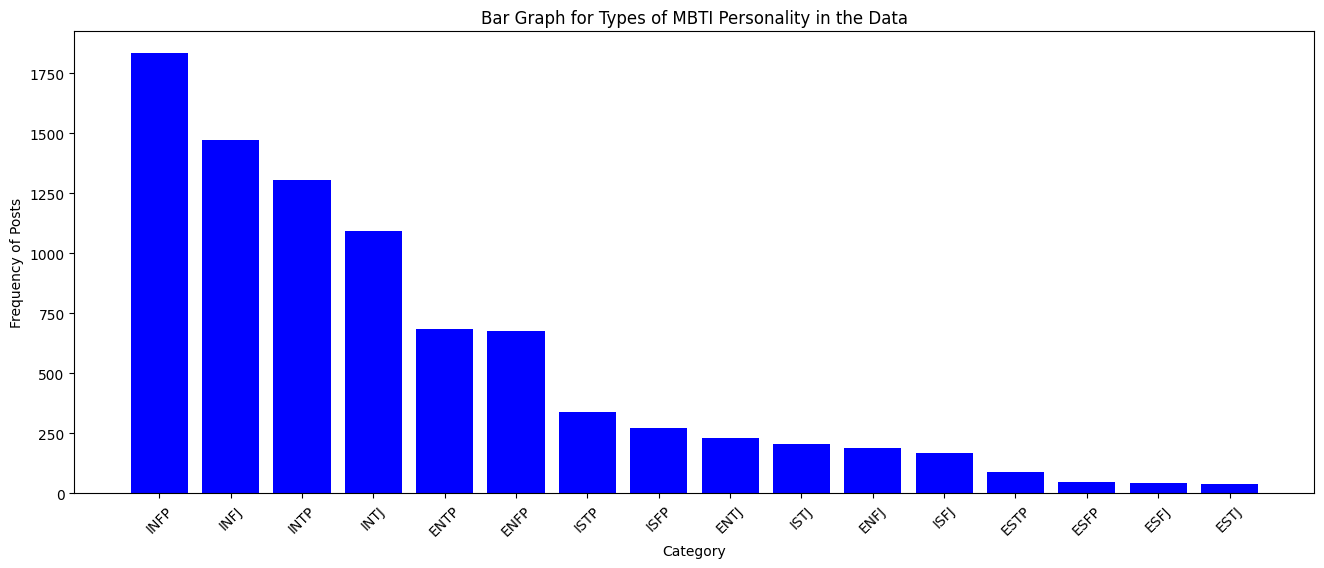

In [21]:
# Plotting frequency of different categories
countCategory = df['type'].value_counts()
print('\n')

print("Number of posts for each MBTI Personality: \n")
print(countCategory)

plt.figure(figsize=(16, 6))
plt.bar(countCategory.index, countCategory.values, color="blue",width=0.8)
plt.xlabel('Category')
plt.ylabel('Frequency of Posts')
plt.title('Bar Graph for Types of MBTI Personality in the Data')
plt.xticks(rotation=45)
plt.show()

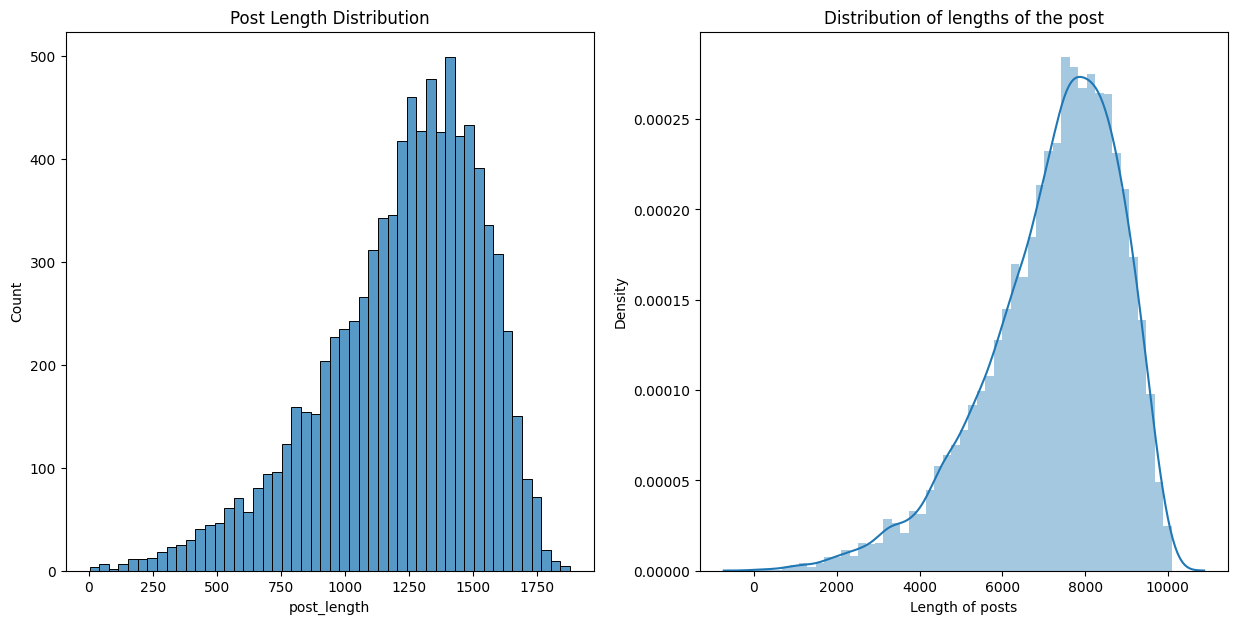

In [23]:
# Ploting the length of the posts 
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
df['post_length'] = df['posts'].apply(lambda x: len(x.split()))
sns.histplot(df['post_length'], bins=50)
plt.title("Post Length Distribution")
plt.subplot(122)
sns.distplot(df["posts"].apply(len))
plt.xlabel("Length of posts")
plt.ylabel("Density")
plt.title("Distribution of lengths of the post")
plt.show()

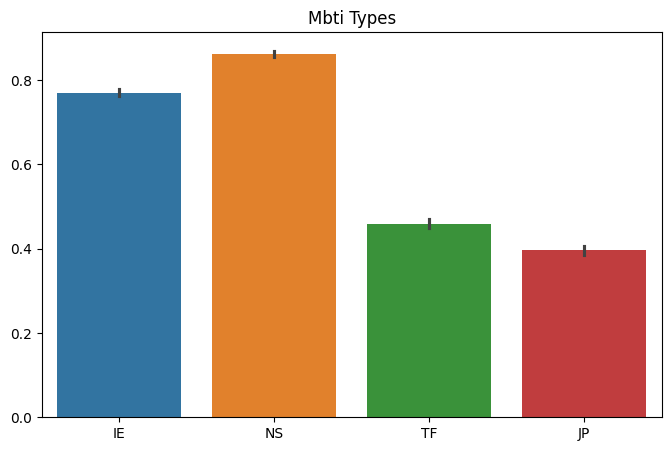

In [24]:
# No of Mbti Types seperately
plt.figure(figsize=(8,5))
sns.barplot(df[['IE', 'NS', 'TF', 'JP']])
plt.title("Mbti Types")
plt.show()

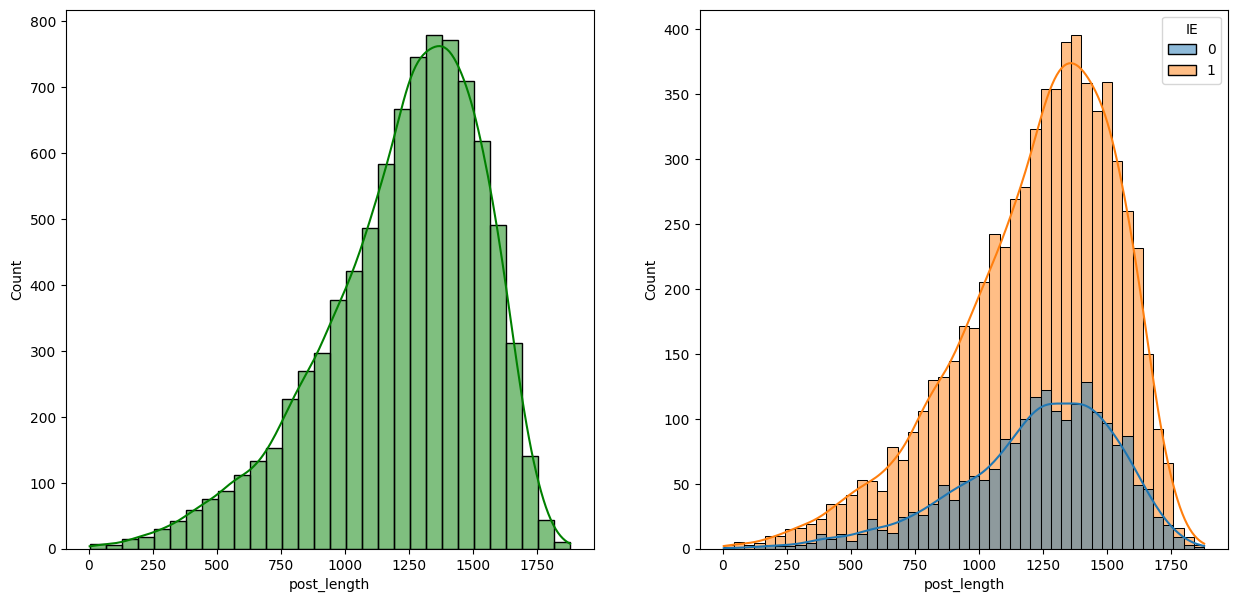

In [25]:
# Ploting post length with respect to IE
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='post_length',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='post_length',kde=True,hue='IE')
plt.show()

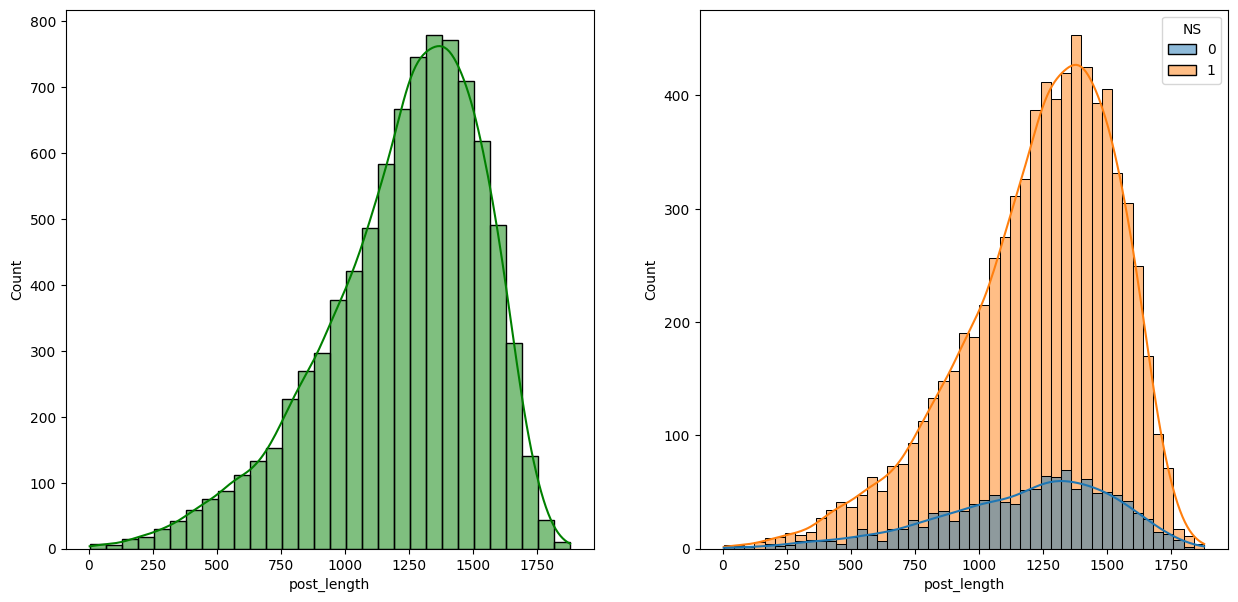

In [26]:
# Ploting post length with respect to NS
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='post_length',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='post_length',kde=True,hue='NS')
plt.show()

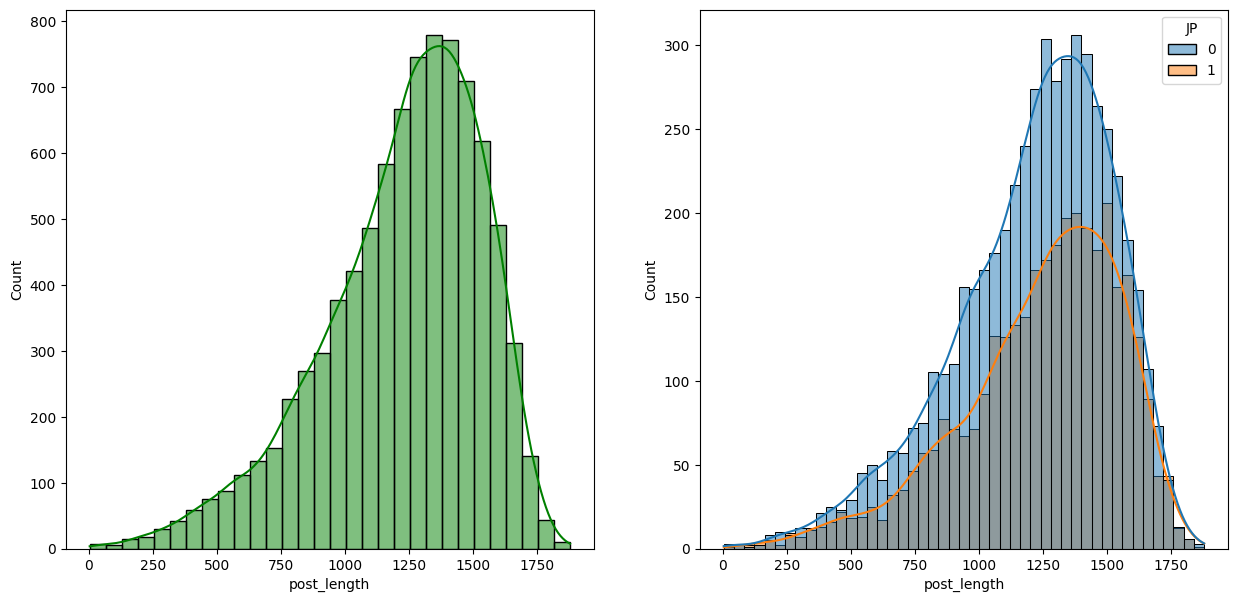

In [27]:
# Ploting post length with respect to JP
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='post_length',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='post_length',kde=True,hue='JP')
plt.show()

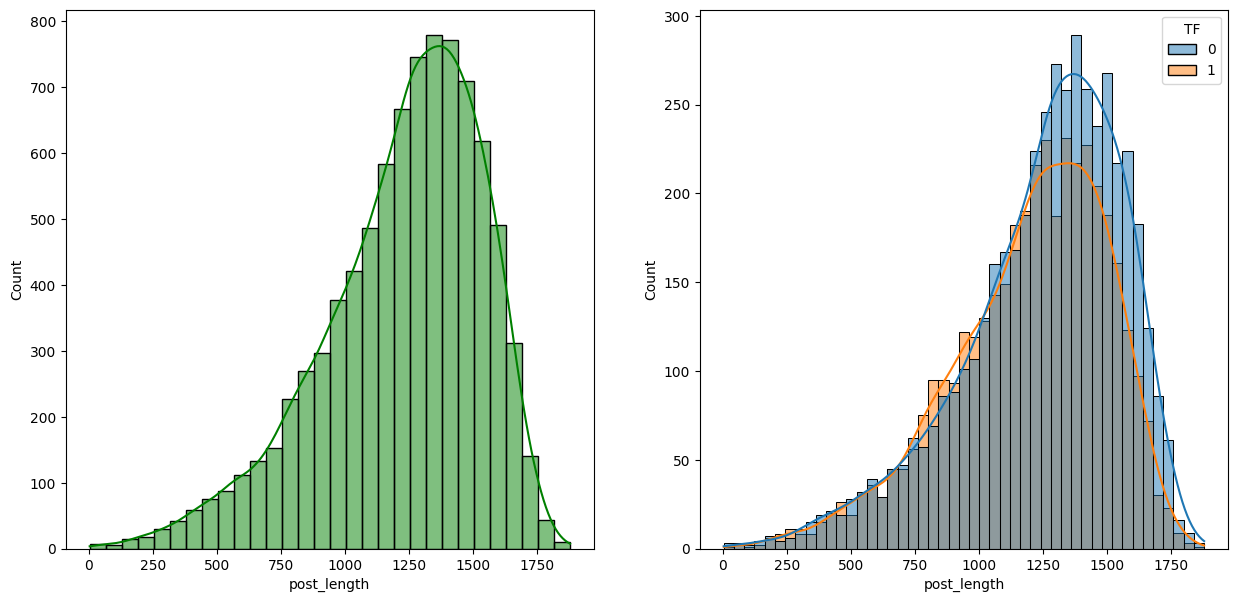

In [28]:
# Ploting post length with respect to TF
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='post_length',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='post_length',kde=True,hue='TF')
plt.show()

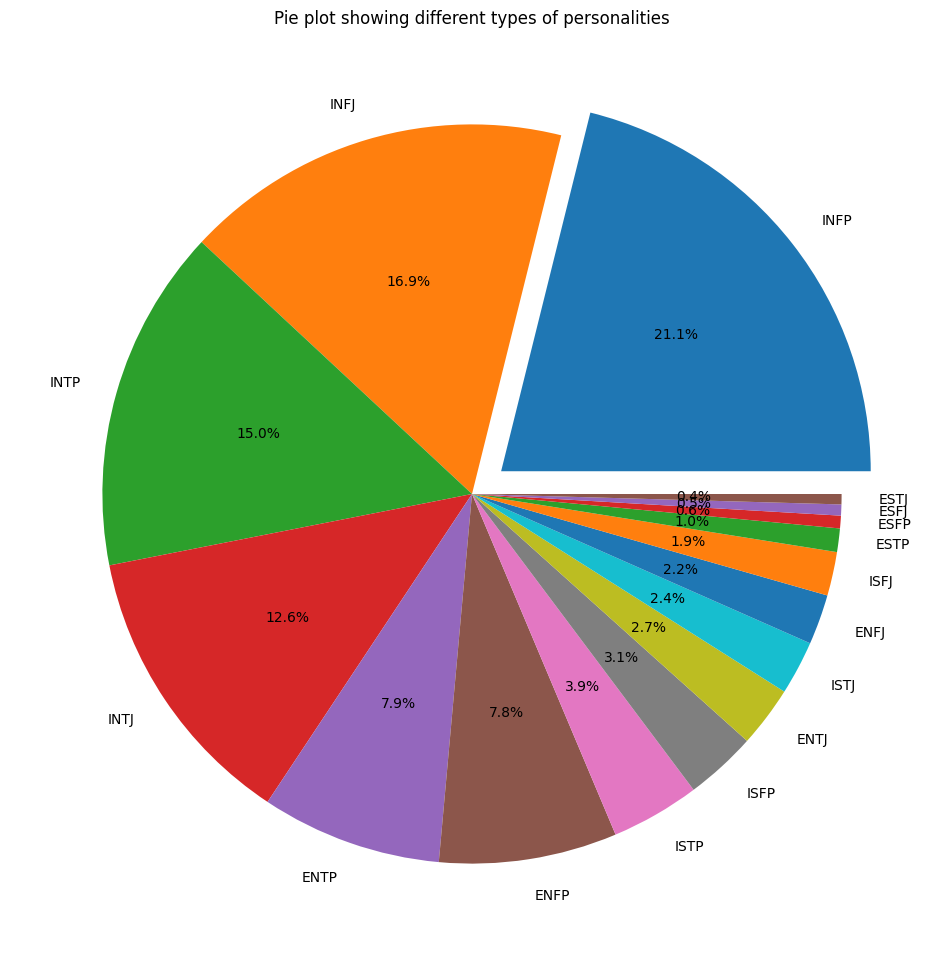

In [29]:
df.type.value_counts().plot(kind='pie',figsize=(12,12), autopct='%1.1f%%', explode=[0.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])
plt.title('Pie plot showing different types of personalities')
plt.show()

In [30]:
df.head()

,type,posts,clean_posts,post_length,IE,NS,TF,JP
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,intj moment sportscenter top ten play prankswh...,556,1,1,0,1
1,ENTP,'I'm finding the lack of me in these posts ver...,finding lack post alarmingsex boring position ...,1170,0,1,1,0
2,INTP,'Good one _____ https://www.youtube.com/wat...,good one course say know thats blessing cursed...,836,1,1,1,0
3,INTJ,"'Dear INTP, I enjoyed our conversation the o...",dear intp enjoyed conversation day esoteric ga...,1064,1,1,1,1
4,ENTJ,'You're fired.|||That's another silly misconce...,youre firedthats another silly misconception a...,967,0,1,1,1


In [34]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.columns

Index(['type', 'posts', 'clean_posts', 'post_length', 'IE', 'NS', 'TF', 'JP'], dtype='str')

In [78]:
vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95,
        stop_words='english'
)

In [79]:
X = vectorizer.fit_transform(df['clean_posts'])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (8675, 5000)


In [80]:
X.shape

(8675, 5000)

In [81]:
feature_names = vectorizer.get_feature_names_out()
feature_df = pd.DataFrame(X.toarray(), columns=feature_names)

In [82]:
X=feature_df

In [83]:
X.shape

(8675, 5000)

In [84]:
feature_df.shape

(8675, 5000)

In [85]:
feature_df.columns

Index(['ability', 'able', 'abouti', 'absolute', 'absolutely',
       'absolutely love', 'absorbed', 'abstract', 'absurd', 'abuse',
       ...
       'youth', 'youtube', 'youve', 'youve got', 'youve said', 'yup', 'zero',
       'zodiac', 'zombie', 'zone'],
      dtype='str', length=5000)

In [86]:
feature_df['IE'] = df['IE']
feature_df['NS'] = df['NS']
feature_df['TF'] = df['TF']
feature_df['JP'] = df['JP']
feature_df["MBTI_type"]=df["type"]
feature_df['original_posts'] = df['posts']
feature_df['clean_posts'] = df['clean_posts']

In [87]:
feature_df.shape

(8675, 5007)

In [88]:
feature_df.to_csv("../Datasets/mbti_tfidf_features.csv", index=False)

print("Feature dataset saved")

Feature dataset saved


In [89]:
feature_df.shape

(8675, 5007)

In [90]:
with open("../artifacts/tfidf_preprocessing_model.pkl","wb") as f:
    pickle.dump(vectorizer, f)

print("Preprocessing model saved successfully")

Preprocessing model saved successfully
